In [1]:
# Customer Purchase Behavior & Revenue Segmentation Analysis

## Day 1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('online_retail.csv')

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.columns 

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.tail(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [8]:
df.size

4335272

In [9]:
df.shape

(541909, 8)

In [10]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df[df['Quantity']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [12]:
df[df['UnitPrice']<=0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
df['Invoice_Year'] = df['InvoiceDate'].dt.year
df['Invoice_Month'] = df['InvoiceDate'].dt.month
df['Invoice_Day'] = df['InvoiceDate'].dt.day
df['Invoice_Hour'] = df['InvoiceDate'].dt.hour

In [15]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Year,Invoice_Month,Invoice_Day,Invoice_Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011,12,9,12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011,12,9,12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,9,12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,9,12


In [16]:
data = df.copy()

In [17]:
data = data[data['Quantity']>0]

In [18]:
data = data[data['UnitPrice']>0]

In [19]:
data = data[data['CustomerID'].notna()]

In [20]:
data.isnull().sum()

InvoiceNo        0
StockCode        0
Description      0
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID       0
Country          0
Invoice_Year     0
Invoice_Month    0
Invoice_Day      0
Invoice_Hour     0
dtype: int64

## Day_1 Insights

1.This dataset represents transactional data from a UK-based online retail store, capturing individual product-level purchase records used for accounting and sales tracking.

2.The dataset contains 541,909 rows and 8 columns. Two columns contain missing values:

a.Description: 1,454 missing values
b.CustomerID: 135,080 missing values

3.Exploratory checks revealed the presence of invalid transactions, including:

a.Rows with negative quantity, indicating cancelled or returned orders
b.Rows with zero or negative unit prices, which are not valid for sales analysis

4.These invalid records were progressively filtered out. Additionally, the InvoiceDate column was converted to a proper datetime format, and new time-based features such as year, month, day, and hour were extracted to support future trend analysis.

5.A separate clean copy of the dataset was created to preserve the raw data. The final cleaned dataset includes only transactions with:
a.Positive quantity
b.Positive unit price
c.Non-missing customer identifiers

6.This cleaning process was necessary because missing values and incorrect records can distort revenue calculations, customer analysis, and feature engineering, leading to skewed or misleading insights. The cleaned dataset will be used for all subsequent analysis in this project.

## Day 2

In [21]:
data['revenue_per_transaction'] = data['Quantity'] * data['UnitPrice']

In [22]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Year,Invoice_Month,Invoice_Day,Invoice_Hour,revenue_per_transaction
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,20.34


In [23]:
data['revenue_per_transaction'].sum()

np.float64(8911407.904)

In [24]:
data['InvoiceNo'].nunique()

18532

In [25]:
data['Description']= data['Description'].str.strip().str.lower()

In [26]:
data['Description'].nunique()

3866

In [27]:
data['CustomerID'].nunique()

4338

In [28]:
data['CustomerID'].isna().sum()

np.int64(0)

In [29]:
revenue_per_invoice = data.groupby('InvoiceNo')['revenue_per_transaction'].sum()

In [30]:
revenue_per_invoice.sort_values(ascending=False).head(2)

InvoiceNo
581483    168469.6
541431     77183.6
Name: revenue_per_transaction, dtype: float64

In [31]:
revenue_per_invoice.mean(),revenue_per_invoice.max(),revenue_per_invoice.min()

(np.float64(480.86595639974104), 168469.6, 0.38)

In [32]:
revenue_per_customer = data.groupby('CustomerID')['revenue_per_transaction'].sum()

In [33]:
revenue_per_customer

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2094.88
18287.0     1837.28
Name: revenue_per_transaction, Length: 4338, dtype: float64

In [34]:
revenue_per_customer.mean(),revenue_per_customer.max(),revenue_per_customer.min()

(np.float64(2054.2664601198708), 280206.02, 3.75)

In [35]:
data.groupby('CustomerID')['InvoiceNo'].nunique()

CustomerID
12346.0     1
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     2
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4338, dtype: int64

In [36]:
data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

Description
paper craft , little birdie           80995
medium ceramic top storage jar        77916
world war 2 gliders asstd designs     54415
jumbo bag red retrospot               46181
white hanging heart t-light holder    36725
assorted colour bird ornament         35362
pack of 72 retrospot cake cases       33693
popcorn holder                        30931
rabbit night light                    27202
mini paint set vintage                26076
Name: Quantity, dtype: int64

In [37]:
data.groupby('Description')['revenue_per_transaction'].sum().sort_values(ascending=False).head(10)

Description
paper craft , little birdie           168469.60
regency cakestand 3 tier              142592.95
white hanging heart t-light holder    100448.15
jumbo bag red retrospot                85220.78
medium ceramic top storage jar         81416.73
postage                                77803.96
party bunting                          68844.33
assorted colour bird ornament          56580.34
manual                                 53779.93
rabbit night light                     51346.20
Name: revenue_per_transaction, dtype: float64

## Day 2 Insights

A revenue column was created by multiplying the quantity sold with the unit price for each transaction, forming the foundation for all further financial analysis.

The total revenue generated by the dataset is £8,911,407.90, indicating a high-volume retail operation. The dataset contains 18,532 unique invoices, 3,866 unique products, and 4,338 unique customers, highlighting a diverse customer base and product range.

Invoice-level analysis revealed significant variation in order values. The highest-value invoice generated £168,469.60, while the average invoice value was substantially lower, suggesting that a small number of large orders contribute heavily to total revenue.

Customer ordering behavior analysis showed that some customers place repeat orders frequently. One customer placed 209 orders, indicating strong customer loyalty and potential high lifetime value.

Product-level analysis showed that “Paper Craft, Little Birdie” is the most frequently sold product by quantity and also the highest revenue-generating product, contributing approximately £168,469.60 in revenue.

Overall, Day 2 analysis indicates that revenue is concentrated among a limited number of products and invoices. Identifying such high-performing products and loyal customers can help the business optimize inventory planning, marketing focus, and customer retention strategies.

## Day 3

In [38]:
data.head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Year,Invoice_Month,Invoice_Day,Invoice_Hour,revenue_per_transaction
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,15.3


In [39]:
data.groupby(['Invoice_Year','Invoice_Month'])['revenue_per_transaction'].sum().sort_values(ascending=True)

Invoice_Year  Invoice_Month
2011          2                 447137.350
              4                 469200.361
              12                518192.790
              1                 569445.040
2010          12                572713.890
2011          3                 595500.760
              7                 600091.011
              8                 645343.900
              6                 661213.690
              5                 678594.560
              9                 952838.382
              10               1039318.790
              11               1161817.380
Name: revenue_per_transaction, dtype: float64

In [40]:
data.groupby('Invoice_Year')['revenue_per_transaction'].sum().sort_values()

Invoice_Year
2010     572713.890
2011    8338694.014
Name: revenue_per_transaction, dtype: float64

In [41]:
a = data.groupby('Invoice_Hour')['revenue_per_transaction'].sum().sort_values()

In [42]:
b= data.groupby('Invoice_Hour')['InvoiceNo'].nunique()

In [43]:
a

Invoice_Hour
6           4.250
20      18932.760
7       31059.210
19      49028.460
18     104954.430
17     234413.521
8      282115.630
16     468885.800
9      842605.171
15     966191.750
14     995629.371
11    1104558.750
13    1173264.750
10    1261192.571
12    1378571.480
Name: revenue_per_transaction, dtype: float64

In [44]:
b.sort_values()

Invoice_Hour
6        1
20      18
7       29
19     144
18     169
17     544
8      555
16    1100
9     1393
15    2037
10    2226
14    2274
11    2277
13    2636
12    3130
Name: InvoiceNo, dtype: int64

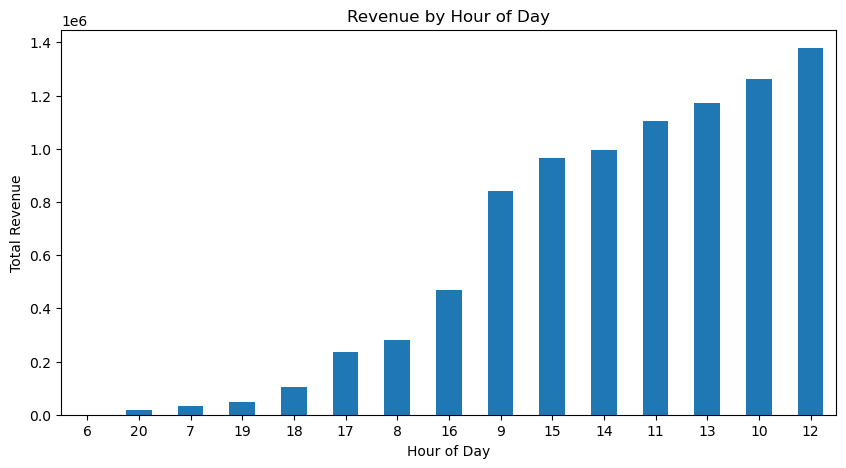

In [45]:
plt.figure(figsize=(10,5))
a.plot(kind='bar')
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()


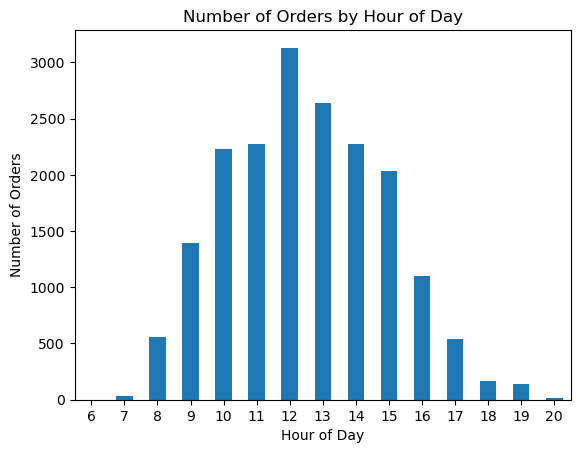

In [46]:
b.plot(kind='bar')
plt.title('Number of Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()


## Day 3 Insights

Revenue analysis shows that 2011 generated significantly higher revenue than 2010. However, the dataset contains only one month of data for 2010, making a direct year-over-year comparison unreliable. This limitation was taken into account during interpretation.

Monthly trend analysis indicates that revenue remains relatively low during the early months of the year (January to March). In contrast, revenue increases steadily from September onward, reaching its peak during the September to November period, indicating strong seasonal demand during the latter part of the year.

Hour-wise analysis of both order count and revenue reveals that the 9 AM to 3 PM time window is the most productive period, accounting for the highest number of orders and revenue generation. This suggests that customers predominantly place orders during standard business hours.

Early morning and late-night hours show significantly lower activity, making them less effective for revenue generation. These trends were confirmed using bar charts representing revenue by hour of day and number of orders by hour of day.

Overall, Day 3 analysis highlights clear seasonal patterns and time-based customer behavior, which can help the business optimize marketing campaigns, staffing, and operational planning.

## Day 4

In [47]:
data.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Year,Invoice_Month,Invoice_Day,Invoice_Hour,revenue_per_transaction
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,15.30
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,20.34


In [48]:
data.groupby('Country')['revenue_per_transaction'].sum().sort_values(ascending=False)

Country
United Kingdom          7308391.554
Netherlands              285446.340
EIRE                     265545.900
Germany                  228867.140
France                   209024.050
Australia                138521.310
Spain                     61577.110
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38378.330
Japan                     37416.370
Norway                    36165.440
Portugal                  33439.890
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20450.440
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13590.380
Austria                   10198.680
Poland                     7334.650
Israel                     7221.690
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590
Unspecified         

In [49]:
uk_based = data[data['Country']=='United Kingdom']

In [50]:
non_uk_based = data[data['Country']!='United Kingdom']

In [51]:
uk_based

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Year,Invoice_Month,Invoice_Day,Invoice_Hour,revenue_per_transaction
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,15.30
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,20.34
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,22.00
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,20.34
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,20.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541889,581585,22466,fairy tale cottage night light,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,2011,12,9,12,23.40
541890,581586,22061,large cake stand hanging strawbery,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom,2011,12,9,12,23.60
541891,581586,23275,set of 3 hanging owls ollie beak,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,2011,12,9,12,30.00
541892,581586,21217,red retrospot round cake tins,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,2011,12,9,12,214.80


In [52]:
non_uk_based.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Year,Invoice_Month,Invoice_Day,Invoice_Hour,revenue_per_transaction
26,536370,22728,alarm clock bakelike pink,24,2010-12-01 08:45:00,3.75,12583.0,France,2010,12,1,8,90.0
27,536370,22727,alarm clock bakelike red,24,2010-12-01 08:45:00,3.75,12583.0,France,2010,12,1,8,90.0
28,536370,22726,alarm clock bakelike green,12,2010-12-01 08:45:00,3.75,12583.0,France,2010,12,1,8,45.0
29,536370,21724,panda and bunnies sticker sheet,12,2010-12-01 08:45:00,0.85,12583.0,France,2010,12,1,8,10.2
30,536370,21883,stars gift tape,24,2010-12-01 08:45:00,0.65,12583.0,France,2010,12,1,8,15.6
31,536370,10002,inflatable political globe,48,2010-12-01 08:45:00,0.85,12583.0,France,2010,12,1,8,40.8
32,536370,21791,vintage heads and tails card game,24,2010-12-01 08:45:00,1.25,12583.0,France,2010,12,1,8,30.0
33,536370,21035,set/2 red retrospot tea towels,18,2010-12-01 08:45:00,2.95,12583.0,France,2010,12,1,8,53.1
34,536370,22326,round snack boxes set of4 woodland,24,2010-12-01 08:45:00,2.95,12583.0,France,2010,12,1,8,70.8
35,536370,22629,spaceboy lunch box,24,2010-12-01 08:45:00,1.95,12583.0,France,2010,12,1,8,46.8


In [53]:
uk_based['revenue_per_transaction'].sum()

np.float64(7308391.5540000005)

In [54]:
non_uk_based['revenue_per_transaction'].sum()

np.float64(1603016.35)

In [55]:
per_uk = ((data['revenue_per_transaction'].sum() - non_uk_based['revenue_per_transaction'].sum())/(data['revenue_per_transaction'].sum())*100)

In [56]:
per_uk

np.float64(82.0116375855664)

In [57]:
data.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

Country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Netherlands          94
Spain                90
Portugal             57
Australia            57
Switzerland          51
Name: InvoiceNo, dtype: int64

### Insights

The United Kingdom dominates overall revenue generation, which is expected since the business is UK-based. This indicates that the company’s core operations and primary customer base are concentrated in the domestic market.

The UK contributes approximately 83% of total revenue, highlighting a strong dependence on a single country. While this reflects market strength, it also indicates potential concentration risk.

International (non-UK) markets contribute the remaining share of revenue, which, although smaller compared to the UK, is still meaningful and suggests healthy overseas demand.

The UK also records the highest number of unique invoices, indicating not only high revenue but also frequent repeat purchasing behavior from domestic customers.

Germany emerges as the strongest international market, ranking second after the UK in terms of unique invoices, suggesting consistent order activity and growth potential in that region.

Overall, the analysis shows that while the business is heavily UK-centric, select international markets demonstrate strong engagement, presenting opportunities for targeted expansion and revenue diversification.

## Day 5

In [58]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Year,Invoice_Month,Invoice_Day,Invoice_Hour,revenue_per_transaction
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,15.30
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,20.34
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,22.00
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,20.34
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,20.34


In [59]:
data.groupby('CustomerID')['revenue_per_transaction'].sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: revenue_per_transaction, dtype: float64

In [60]:
data.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False).head()

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
Name: InvoiceNo, dtype: int64

In [61]:
invoice_revenue = data.groupby(
    ['CustomerID', 'InvoiceNo']
)['revenue_per_transaction'].sum()

In [62]:
aov_per_customer = invoice_revenue.groupby('CustomerID').mean()

In [63]:
aov_per_customer

CustomerID
12346.0    77183.600000
12347.0      615.714286
12348.0      449.310000
12349.0     1757.550000
12350.0      334.400000
               ...     
18280.0      180.600000
18281.0       80.820000
18282.0       89.025000
18283.0      130.930000
18287.0      612.426667
Name: revenue_per_transaction, Length: 4338, dtype: float64

In [64]:
data.groupby('CustomerID')['revenue_per_transaction'].sum()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2094.88
18287.0     1837.28
Name: revenue_per_transaction, Length: 4338, dtype: float64

In [65]:
data.groupby('CustomerID')['InvoiceNo'].count()

CustomerID
12346.0      1
12347.0    182
12348.0     31
12349.0     73
12350.0     17
          ... 
18280.0     10
18281.0      7
18282.0     12
18283.0    756
18287.0     70
Name: InvoiceNo, Length: 4338, dtype: int64

In [66]:
data.groupby("CustomerID")['revenue_per_transaction'].sum()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2094.88
18287.0     1837.28
Name: revenue_per_transaction, Length: 4338, dtype: float64

## INSIGHTS

A small group of customers contributes a large share of total revenue, indicating revenue concentration among key accounts.

The most frequent customers are not always the highest revenue contributors, showing different buying behaviors.

Some customers generate high revenue with fewer orders, suggesting bulk or high-value purchases.

Many customers place frequent but lower-value orders, indicating strong loyalty but lower average spend.

Revenue distribution follows a long-tail pattern, with most customers contributing small amounts.

These insights highlight opportunities for retaining high-value customers, rewarding loyal buyers, and increasing average order value through targeted upselling.

## DAY 6

In [67]:
# -----------------------------
# DAY 6: RFM ANALYSIS
# -----------------------------

# 1) Snapshot date = one day after the most recent purchase
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

# 2) Build customer-level RFM table
rfm = data.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('revenue_per_transaction', 'sum')
).reset_index()

# 3) Score R, F, M using quartiles
# Recency: lower is better, so reverse the scores
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])

# 4) Combine scores
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)

# 5) Create simple customer segments
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk High Value'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# 6) View the final RFM table
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,1,77183.60,1,1,4,11,Others
1,12347.0,2,7,4310.00,4,4,4,44,Champions
2,12348.0,75,4,1797.24,2,3,4,23,At Risk High Value
3,12349.0,19,1,1757.55,3,1,4,31,Others
4,12350.0,310,1,334.40,1,1,2,11,Hibernating


In [68]:
# Segment summary
segment_summary = rfm.groupby('Segment').agg(
    Customers=('CustomerID', 'nunique'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Monetary=('Monetary', 'sum')
).sort_values('Total_Monetary', ascending=False)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary
Segment,,,,,
Champions,478,7.169456,15.719665,9190.882573,4393241.870
Loyal Customers,1036,22.335907,5.246139,2117.634094,2193868.921
At Risk High Value,453,105.461369,4.704194,2140.598013,969690.900
Others,1070,79.327103,1.747664,718.565282,768864.852
Hibernating,1247,193.865277,1.186848,285.739560,356317.231
Potential Loyalists,54,8.370370,1.888889,4248.595000,229424.130


In [69]:
# Segment-wise customer count
rfm['Segment'].value_counts()

Segment
Hibernating            1247
Others                 1070
Loyal Customers        1036
Champions               478
At Risk High Value      453
Potential Loyalists      54
Name: count, dtype: int64

In [70]:
# Top 10 customers by monetary value
rfm.sort_values('Monetary', ascending=False).head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
1689,14646.0,2,73,280206.02,4,4,4,44,Champions
4201,18102.0,1,60,259657.30,4,4,4,44,Champions
3728,17450.0,8,46,194550.79,4,4,4,44,Champions
3008,16446.0,1,2,168472.50,4,2,4,42,Potential Loyalists
1879,14911.0,1,201,143825.06,4,4,4,44,Champions
55,12415.0,24,21,124914.53,3,4,4,34,Loyal Customers
1333,14156.0,10,55,117379.63,4,4,4,44,Champions
3771,17511.0,3,31,91062.38,4,4,4,44,Champions
2702,16029.0,39,63,81024.84,3,4,4,34,Loyal Customers
0,12346.0,326,1,77183.60,1,1,4,11,Others


In [71]:
# Revenue share by segment
segment_summary['Revenue_Share_%'] = (
    segment_summary['Total_Monetary'] / segment_summary['Total_Monetary'].sum() * 100
)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Revenue_Share_%
Segment,,,,,,
Champions,478,7.169456,15.719665,9190.882573,4393241.870,49.299077
Loyal Customers,1036,22.335907,5.246139,2117.634094,2193868.921,24.618657
At Risk High Value,453,105.461369,4.704194,2140.598013,969690.900,10.881456
Others,1070,79.327103,1.747664,718.565282,768864.852,8.627872
Hibernating,1247,193.865277,1.186848,285.739560,356317.231,3.998439
Potential Loyalists,54,8.370370,1.888889,4248.595000,229424.130,2.574499


In [72]:
# Top 10 customers by frequency
rfm.sort_values('Frequency', ascending=False).head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
326,12748.0,1,209,33719.73,4,4,4,44,Champions
1879,14911.0,1,201,143825.06,4,4,4,44,Champions
4010,17841.0,2,124,40991.57,4,4,4,44,Champions
562,13089.0,3,97,58825.83,4,4,4,44,Champions
1661,14606.0,1,93,12156.65,4,4,4,44,Champions
2176,15311.0,1,91,60767.90,4,4,4,44,Champions
481,12971.0,4,86,11189.91,4,4,4,44,Champions
1689,14646.0,2,73,280206.02,4,4,4,44,Champions
2702,16029.0,39,63,81024.84,3,4,4,34,Loyal Customers
795,13408.0,2,62,28117.04,4,4,4,44,Champions


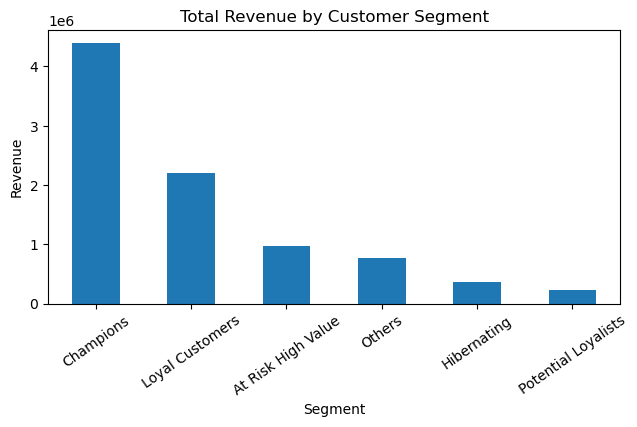

In [74]:
import matplotlib.pyplot as plt

segment_summary['Total_Monetary'].sort_values(ascending=False).plot(kind='bar')
plt.title('Total Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Revenue')
plt.tight_layout()
plt.xticks(rotation=35)
plt.show()

# 📊 Day 6 – RFM Analysis Insights

---

## 🎯 Objective
RFM analysis was used to segment customers based on:
- **Recency**
- **Frequency**
- **Monetary Value**

This helped identify active, loyal, high-value, and at-risk customers.

---

## 💎 Key Insights

### 1️⃣ Revenue Concentration
A small group of high-value customers contributes a large share of total revenue, indicating strong revenue concentration among key accounts.

---

### 2️⃣ Champions & Loyal Customers
Customers classified as **Champions** and **Loyal Customers** contribute the majority of revenue and should be retained using loyalty and personalized engagement strategies.

---

### 3️⃣ At-Risk High-Value Customers
Customers in the **At Risk High Value** segment generated significant revenue in the past but have not purchased recently. These customers represent strong reactivation opportunities.

---

### 4️⃣ Hibernating Customers
The **Hibernating** segment contains customers with low engagement and relatively lower revenue contribution.

---

## 📈 Business Conclusion
RFM segmentation provides a structured way to prioritize:
- Customer retention
- Reactivation campaigns
- Personalized marketing
- Upselling opportunities

This helps the business improve customer lifetime value and revenue optimization.

# 📊 Day 7 & Day 8 — Visual Storytelling, Final Summary & Conclusion

## 🎯 Objective
The objective of this final section is to present the key findings from the online retail analysis through visual interpretation and summarize the overall business insights derived from the dataset.

---

## 📈 Visual Storytelling Insights

### 1. Monthly Revenue Trend
The monthly revenue trend shows clear seasonal variation in sales performance. Revenue is stronger in the later months of the year, especially between September and November, while the early months show comparatively lower performance. This suggests strong seasonal demand in the business.

### 2. Revenue by Country
Country-wise analysis shows that the United Kingdom dominates total revenue generation, which is expected for a UK-based retail business. Germany stands out as the strongest international market, indicating meaningful overseas demand and growth potential.

### 3. Orders by Hour
Hourly analysis reveals that most orders and revenue are generated between 9 AM and 3 PM. Early morning and late-night hours show lower activity, suggesting that customers are most active during standard business hours.

### 4. Top Products
Product-level analysis shows that a small number of products contribute significantly to total revenue. “Paper Craft, Little Birdie” is one of the highest-performing products in terms of both quantity sold and revenue generated, highlighting its importance in the business.

### 5. Customer Segments
RFM segmentation identifies that Champions and Loyal Customers contribute a major share of revenue. At the same time, a large group of customers falls into low-engagement or hibernating categories, creating opportunities for retention and reactivation campaigns.

---

## 🧠 Final Business Summary

This project analyzed transactional data from a UK-based online retail business to understand revenue performance, customer behavior, product trends, geographical contribution, and time-based purchasing patterns.

The analysis showed that:
- The business generated over **£8.9 million** in total revenue.
- Revenue is concentrated among a relatively small number of customers and products.
- The **United Kingdom** contributes the majority of revenue, while **Germany** is the most important international market.
- Sales activity is strongest during **September to November** and between **9 AM and 3 PM**.
- Repeat and high-value customers play a critical role in overall business performance.

RFM analysis further showed that the customer base can be segmented into valuable groups such as Champions, Loyal Customers, At-Risk High Value Customers, and Hibernating Customers. These segments provide a practical foundation for targeted marketing and retention strategies.

---

## 💼 Business Recommendations

Based on the analysis, the following recommendations can be made:

- Focus retention efforts on high-value and loyal customers.
- Increase promotional and inventory planning during peak seasonal months.
- Strengthen marketing efforts in high-performing international markets such as Germany.
- Use personalized reactivation campaigns for at-risk customers.
- Prioritize top-selling products in inventory and sales planning.
- Target business-hour shopping patterns for campaigns and promotions.

---

## ✅ Final Conclusion

The Online Retail Data Analysis project successfully converted raw transactional data into meaningful business insights using data cleaning, exploratory analysis, customer analysis, time-based trends, country-wise analysis, and RFM segmentation.

This project demonstrates how data-driven decision-making can help a retail business improve revenue planning, customer retention, product strategy, and operational efficiency.

It also reflects practical data analyst skills in:
- Data cleaning
- Exploratory data analysis
- Business interpretation
- Customer segmentation
- Visual storytelling
- Insight generation